# Exercícios — Bagging e Random Forest

**Tema:** Aprendizado Supervisionado › Bagging e Random Forest

Resolva antes de olhar o gabarito. **Dificuldade:** 🟢 base · 🟡 aplicação ·
🔴 síntese

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.inspection import permutation_importance
from sklearn.datasets import make_classification

rng = np.random.default_rng(1515)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
AZUL, VERDE, VERMELHO, ROXO, AMBAR = "#1F5C8B", "#1E6B4F", "#9C2B2B", "#5B3E86", "#8A6100"
print("ambiente pronto")

ambiente pronto


---
## Exercício 1 🟢 — A fração out-of-bag é mesmo ~36,8%?

Para uma amostra bootstrap de tamanho $n$, simule (para $n=1000$, com
500 repetições) a fração de observações originais que NUNCA são
sorteadas. Compare com $e^{-1}$.

In [2]:
# --- sua resposta ---

### Gabarito 1

In [3]:
n = 1000
fracoes_oob = []
for _ in range(500):
    indices_sorteados = rng.integers(0, n, n)
    fracao_fora = 1 - len(np.unique(indices_sorteados)) / n
    fracoes_oob.append(fracao_fora)

print(f"fração OOB observada (média de 500 simulações): {np.mean(fracoes_oob):.4f}")
print(f"e^-1 (limite teórico quando n -> infinito)     : {np.exp(-1):.4f}")

fração OOB observada (média de 500 simulações): 0.3679
e^-1 (limite teórico quando n -> infinito)     : 0.3679


---
## Exercício 2 🟢 — Bagging não ajuda um modelo de baixa variância

Compare o ganho de bagging aplicado a uma árvore de decisão (`teoria.pdf`:
viés baixo, variância alta) com bagging aplicado a uma regressão logística
(viés mais alto, variância mais baixa). Em qual o ganho deveria ser maior?

In [4]:
# --- sua resposta ---

### Gabarito 2

In [5]:
from sklearn.linear_model import LogisticRegression

X, y = make_classification(n_samples=500, n_features=10, n_informative=6,
                           n_redundant=0, random_state=0)

for nome_base, base in [("árvore de decisão", DecisionTreeClassifier()),
                        ("regressão logística", LogisticRegression(max_iter=1000))]:
    acc_base = cross_val_score(base, X, y, cv=5).mean()
    acc_bagging = cross_val_score(
        BaggingClassifier(base, n_estimators=50, random_state=0), X, y, cv=5).mean()
    print(f"{nome_base:<22s} sozinho={acc_base:.4f}   com bagging={acc_bagging:.4f}   "
          f"ganho={acc_bagging - acc_base:+.4f}")

árvore de decisão      sozinho=0.8480   com bagging=0.8780   ganho=+0.0300


regressão logística    sozinho=0.8060   com bagging=0.8120   ganho=+0.0060


**Resposta esperada:** o ganho de bagging deve ser bem maior para a árvore
de decisão — ela tem mais variância "disponível" para ser reduzida. A
regressão logística, já estável e de viés mais alto, ganha pouco ou quase
nada com bagging, confirmando a intuição do `teoria.pdf`.

---
## Exercício 3 🟡 — max_features e a correlação entre árvores

Usando o dataset com feature dominante do notebook-guia, varie
`max_features` de 1 até o total de features e meça a correlação média
entre árvores em cada caso. Confirme que `max_features` menor produz
árvores menos correlacionadas.

In [6]:
# --- sua resposta ---

### Gabarito 3

In [7]:
n = 800
feature_dominante = rng.normal(0, 1, n)
features_fracas = rng.normal(0, 1, (n, 9)) * 0.3
X = np.column_stack([feature_dominante, features_fracas])
y = (feature_dominante + features_fracas.sum(axis=1) * 0.3 > 0).astype(int)


def correlacao_media(previsoes, n_pares=300, seed=0):
    rng_local = np.random.default_rng(seed)
    n_arvores = len(previsoes)
    corrs = [np.corrcoef(previsoes[i], previsoes[j])[0, 1]
            for i, j in (rng_local.choice(n_arvores, 2, replace=False) for _ in range(n_pares))]
    return np.mean(corrs)


print(f"{'max_features':>14s} {'correlação média':>18s}")
print("-" * 34)
for mf in [1, 2, 4, 6, 10]:
    modelo = RandomForestClassifier(n_estimators=80, max_features=mf, random_state=0).fit(X, y)
    previsoes = np.array([arv.predict(X) for arv in modelo.estimators_])
    print(f"{mf:>14d} {correlacao_media(previsoes):>18.4f}")

  max_features   correlação média
----------------------------------


             1             0.6981


             2             0.7955


             4             0.8775


             6             0.8935


            10             0.9042


---
## Exercício 4 🟡 — Random Forest para regressão: intervalos a partir das árvores

Random Forest não é só para classificação. Treine um
`RandomForestRegressor` e, em vez de só usar a média das árvores como
previsão pontual, calcule também o **desvio-padrão entre as árvores** para
cada ponto de teste — uma medida crua (mas útil) de incerteza da previsão.

In [8]:
# --- sua resposta ---

### Gabarito 4

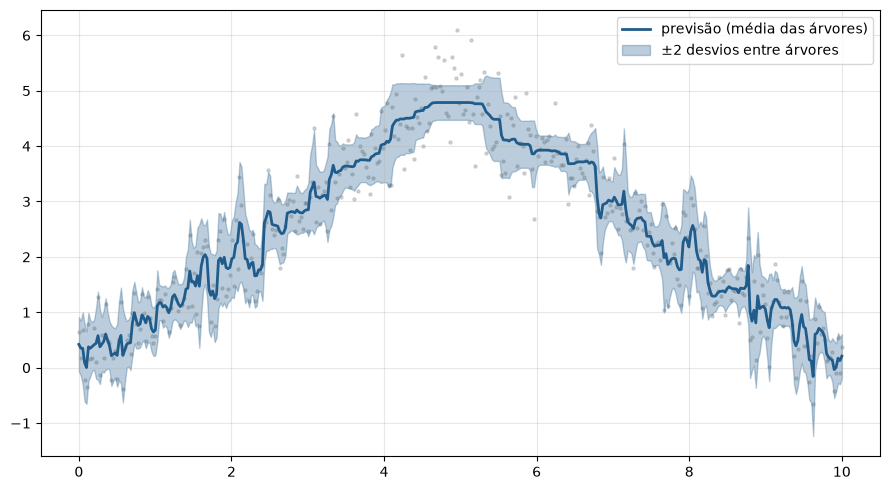

incerteza média no MEIO do domínio (perto do pico): 0.1562
incerteza média nas BORDAS do domínio              : 0.2827


In [9]:
x = np.linspace(0, 10, 400).reshape(-1, 1)
y_verdadeiro = np.where(x.ravel() < 5, x.ravel(), 10 - x.ravel())  # forma em "V invertido"
y_ruidoso = y_verdadeiro + rng.normal(0, 0.5, len(x))

rf_regressor = RandomForestRegressor(n_estimators=200, max_depth=6, random_state=0).fit(
    x, y_ruidoso)
previsoes_arvores = np.array([arv.predict(x) for arv in rf_regressor.estimators_])
media_previsao = previsoes_arvores.mean(axis=0)
incerteza = previsoes_arvores.std(axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y_ruidoso, s=5, alpha=0.3, color="gray")
ax.plot(x, media_previsao, color=AZUL, lw=2, label="previsão (média das árvores)")
ax.fill_between(x.ravel(), media_previsao - 2 * incerteza, media_previsao + 2 * incerteza,
                alpha=0.3, color=AZUL, label="±2 desvios entre árvores")
ax.legend(); plt.tight_layout(); plt.show()

print(f"incerteza média no MEIO do domínio (perto do pico): {incerteza[200]:.4f}")
print(f"incerteza média nas BORDAS do domínio              : "
      f"{(incerteza[5] + incerteza[-5]) / 2:.4f}")

**Leitura esperada:** a incerteza (desvio entre árvores) tende a ser maior
perto do "cotovelo" da função em V invertido, onde a relação muda
abruptamente e árvores diferentes discordam mais sobre onde colocar o
corte — uma medida crua, mas informativa, de onde o modelo está menos
confiante.

---
## Exercício 5 🔴 — Auditoria: MDI mentindo em um cenário de negócio

Um analista de crédito reporta: "`id_regional_da_agencia` é a segunda
feature mais importante do nosso modelo de aprovação de crédito, com MDI
de 0,15". Investigue se isso é confiável, considerando que
`id_regional_da_agencia` tem 200 valores possíveis, contra 5-10 das demais
features. Construa um cenário sintético parecido e compare MDI com
importância por permutação.

In [10]:
# --- sua resposta ---

### Gabarito 5

In [11]:
n = 3000
renda = rng.normal(5000, 2000, n)
n_atrasos = rng.integers(0, 5, n)
id_regional = rng.integers(0, 200, n)  # ALTA cardinalidade, SEM relação real com o alvo

logit = -1.5 + 0.0003 * renda - 0.4 * n_atrasos
aprovado = (rng.random(n) < 1 / (1 + np.exp(-logit))).astype(int)

X = pd.DataFrame({"renda": renda, "n_atrasos": n_atrasos, "id_regional": id_regional})
X_treino, X_teste, y_treino, y_teste = train_test_split(X, aprovado, test_size=0.3, random_state=0)

modelo = RandomForestClassifier(n_estimators=300, random_state=0).fit(X_treino, y_treino)
mdi = pd.Series(modelo.feature_importances_, index=X.columns).sort_values(ascending=False)
perm = permutation_importance(modelo, X_teste, y_teste, n_repeats=30, random_state=0,
                              scoring="roc_auc")
importancia_perm = pd.Series(perm.importances_mean, index=X.columns).sort_values(
    ascending=False)

print("MDI:")
print(mdi.round(4).to_string())
print("\npermutação (queda de AUC):")
print(importancia_perm.round(4).to_string())

MDI:
renda          0.524
id_regional    0.395
n_atrasos      0.081

permutação (queda de AUC):
n_atrasos      0.0938
renda          0.0660
id_regional    0.0179


**Resposta esperada:** MDI provavelmente atribui a `id_regional` uma
importância bem maior que zero (por causa da alta cardinalidade), mesmo
ela sendo, por construção, irrelevante para `aprovado`. A importância por
permutação deveria colocá-la perto de zero. O analista do enunciado
provavelmente está sendo enganado pelo mesmo viés — a recomendação é
recalcular a importância por permutação antes de tomar qualquer decisão de
negócio (como usar ou não a região da agência como critério, o que também
levanta questões de fairness, tema 11).

---
## Fechamento

- A fração out-of-bag de ~36,8% não é uma regra empírica — é uma
  consequência direta e verificável de amostragem com reposição.
- Bagging ajuda modelos de alta variância; ganha pouco em modelos já
  estáveis, como regressão logística.
- `max_features` é o parâmetro que efetivamente reduz a correlação entre
  árvores — mensurável diretamente, não só uma promessa teórica.
- A dispersão entre árvores de um Random Forest é uma medida crua, mas
  real, de incerteza da previsão.
- MDI enganosamente favorece features de alta cardinalidade mesmo em
  Random Forest — qualquer decisão de negócio baseada em importância de
  features deveria usar permutação, não MDI, como evidência.

→ Próximo módulo: **Boosting**, a última e mais poderosa família de
ensembles de árvores deste tema.